# AML Transaction Monitoring

**Pattern-level transparency for suspicious activity review**

## Part 0 — Setup

In [1]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_recall_curve, confusion_matrix,
    precision_recall_fscore_support, accuracy_score,
)
warnings.filterwarnings('ignore')

from hugiml import HUGIMLClassifier
from hugiml.calibration import evaluate_calibration
from hugiml.metrics import compute_all_metrics
from hugiml.pruning import PatternEditor
from hugiml.governance import generate_model_card

RANDOM_STATE = 42
DATA_FILE     = 'nb05_aml_data.csv'
METADATA_FILE = 'nb05_aml_metadata.csv'
TARGET        = 'suspicious'

TYPOLOGY_MAP = {
    'structuring_score': 'Structuring / CTR Evasion',
    'amount':            'Structuring / CTR Evasion',
    'velocity_24h':      'Velocity Abuse / Rapid Movement',
    'account_age_days':  'New-Account Exploitation',
    'num_previous_transactions': 'Layering / Sparse History',
    'hour_of_day':       'Off-Hours Activity',
    'country':           'Geographic Risk / Offshore Routing',
    'high_risk_country': 'Offshore Jurisdiction Flag',
    'avg_monthly_balance': 'Balance Anomaly',
    'customer_age':      'Demographic Profiling (review required)',
    'transaction_type':  'Transaction-Type Risk',
    'customer_type':     'Customer Segment Risk',
}

THEME = dict(bg='#fbf7ef',panel='#fffdf8',text='#23312a',muted='#6b5f4b',
             accent='#9a6a2f',accent2='#2f6b54',accent3='#7a2f2f',grid='#e5dccb')
plt.rcParams.update({'figure.facecolor':THEME['bg'],'axes.facecolor':THEME['panel'],
                     'axes.edgecolor':THEME['grid'],'font.size':10})

import hugiml; print('hugiml-core', hugiml.__version__)


hugiml-core 1.1.2


## Part 1 — Data Loading and Quality Review

In [3]:
df = pd.read_csv(DATA_FILE)
metadata = pd.read_csv(METADATA_FILE)
df[TARGET] = df[TARGET].astype(int)

n_rows, n_cols = df.shape
feature_count  = n_cols - 1
num_feats   = df.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
cat_feats   = [c for c in df.drop(columns=[TARGET]).columns if c not in num_feats]
target_rate = df[TARGET].mean()

print(f'Rows: {n_rows:,}  |  Features: {feature_count}  ({len(num_feats)} numeric, {len(cat_feats)} categorical)')
print(f'Suspicious rate: {target_rate:.2%}  (realistic for deployed AML systems)')
print(f'Missing cells: {int(df.isna().sum().sum())}  |  Duplicates: {int(df.duplicated().sum())}')

print('\nFeature register:')
display_cols = [c for c in ['column_name','data_type','description','importance','notes'] if c in metadata.columns]
print(metadata[display_cols].to_string(index=False))
df.head(5)


Rows: 10,000  |  Features: 12  (9 numeric, 3 categorical)
Suspicious rate: 5.00%  (realistic for deployed AML systems)
Missing cells: 0  |  Duplicates: 0

Feature register:
              column_name   data_type                                 description            importance                                                       notes
                   amount   numerical                   Transaction amount in USD              Critical    Amounts $9,000-$9,950 indicate structuring (CTR evasion)
             velocity_24h   numerical     Number of transactions in past 24 hours                  High          High velocity (9-16) indicates suspicious activity
        structuring_score   numerical       Composite structuring detection score              Critical                     Scores >0.73 are highest risk indicator
         account_age_days   numerical                      Age of account in days                  High         Accounts <20 days with high activity are suspicious
      a

,amount,velocity_24h,account_age_days,structuring_score,avg_monthly_balance,num_previous_transactions,customer_age,hour_of_day,country,high_risk_country,customer_type,transaction_type,suspicious
0,3487.089205,2,97.010190,0.096204,3231.939003,27,21,8,UK,0,retail,ach,0
1,14.075010,4,858.884432,0.324218,1196.862210,24,61,9,US,0,retail,wire,0
2,39.489105,6,564.260120,0.123154,360.048094,16,47,12,US,0,retail,wire,0
3,66.848479,4,151.002059,0.036690,747.826758,20,34,8,US,0,retail,ach,0
4,334.119765,2,290.645733,0.123174,1700.486387,33,46,15,US,0,business,check,0


## Part 2 — Splits (60/20/20)

> **Forward-looking validation:** Production AML models are validated against a forward window
> of confirmed SAR dispositions. Without explicit timestamps, we use a stratified random
> split with a **separate calibration holdout** for isotonic recalibration used in
> SAR filing threshold analysis.


In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

clf_prep = HUGIMLClassifier(B=10, L=1, G=5e-4, topK=100)
X_enc, y_enc = clf_prep.prepareXy(X, y)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_enc, y_enc, test_size=0.40, stratify=y_enc, random_state=RANDOM_STATE
)
X_cal, X_te, y_cal, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=RANDOM_STATE
)
print(f'Train: {len(X_tr):,}  |  Calibration: {len(X_cal):,}  |  Test: {len(X_te):,}')
print(f'Test positives: {y_te.sum()} ({y_te.mean():.2%})')


Train: 6,000  |  Calibration: 2,000  |  Test: 2,000
Test positives: 100 (5.00%)


## Part 3 — feature_mode Comparison

For AML investigator review, **`patterns_only`** gives the cleanest pattern-level
explanation per transaction. `original_plus_patterns` can improve AUC marginally
but makes adverse-action justification more complex.


In [7]:
mode_results = {}
for mode in ['patterns_only', 'original_plus_patterns']:
    c = HUGIMLClassifier(B=10, L=1, G=5e-4, topK=100, feature_mode=mode)
    Xe, ye = c.prepareXy(X, y)
    Xtr2,Xtmp2,ytr2,ytmp2 = train_test_split(Xe,ye,test_size=0.40,stratify=ye,random_state=RANDOM_STATE)
    Xcal2,Xte2,ycal2,yte2 = train_test_split(Xtmp2,ytmp2,test_size=0.50,stratify=ytmp2,random_state=RANDOM_STATE)
    c.fit(Xtr2, ytr2)
    p2 = c.predict_proba(Xte2)[:, 1]
    mode_results[mode] = dict(clf=c,Xtr=Xtr2,Xcal=Xcal2,Xte=Xte2,
                               ytr=ytr2,ycal=ycal2,yte=yte2,proba=p2,
                               auc=roc_auc_score(yte2,p2),
                               ap=average_precision_score(yte2,p2))
    print(f"  {mode:26s}: {len(c.get_hug_features()):3d} patterns | "
          f"AUC={mode_results[mode]['auc']:.4f} | AP={mode_results[mode]['ap']:.4f}")

# Work with patterns_only for audit clarity
R = mode_results['patterns_only']
clf,X_tr,X_cal,X_te = R['clf'],R['Xtr'],R['Xcal'],R['Xte']
y_tr,y_cal,y_te,y_score = R['ytr'],R['ycal'],R['yte'],R['proba']
auc,ap = R['auc'],R['ap']

fpr_c,tpr_c,thr_c = roc_curve(y_te,y_score)
prec_c,rec_c,thr_pr = precision_recall_curve(y_te,y_score)
youden_idx = int(np.argmax(tpr_c-fpr_c))
op_threshold = float(thr_c[youden_idx]) if np.isfinite(thr_c[youden_idx]) else 0.50
y_pred = (y_score >= op_threshold).astype(int)
tn,fp,fn,tp = confusion_matrix(y_te,y_pred).ravel()
prec_op,rec_op,f1_op,_ = precision_recall_fscore_support(y_te,y_pred,average='binary',zero_division=0)
print(f'\nBaseline @ Youden threshold {op_threshold:.3f}:')
print(f'  AUC={auc:.4f}  AP={ap:.4f}  precision={prec_op:.2%}  recall={rec_op:.2%}  F1={f1_op:.3f}')
print(f'  TP={tp}  FP={fp}  TN={tn}  FN={fn}')


  patterns_only             :  73 patterns | AUC=0.9987 | AP=0.9773
  original_plus_patterns    :  73 patterns | AUC=0.9996 | AP=0.9948

Baseline @ Youden threshold 0.222:
  AUC=0.9987  AP=0.9773  precision=92.45%  recall=98.00%  F1=0.951
  TP=98  FP=8  TN=1892  FN=2


## Part 4 — Calibration (Pre-Recalibration Baseline)

In [9]:
cal_pre = evaluate_calibration(np.asarray(y_te), y_score)
print(f'ECE={cal_pre.ece:.4f}  MCE={cal_pre.mce:.4f}  Brier={cal_pre.brier_score:.4f}')
print('Well-calibrated scores are critical for SAR filing threshold analysis.')


ECE=0.0067  MCE=0.4635  Brier=0.0051
Well-calibrated scores are critical for SAR filing threshold analysis.


## Part 5 — Interpretability Metrics

In [11]:
interp = compute_all_metrics(clf, X_te)
print(f'n_patterns          : {interp.n_patterns}')
print(f'avg_pattern_length  : {interp.avg_pattern_length:.2f}')
print(f'coverage            : {interp.coverage:.2%}')
print(f'mean_active/sample  : {interp.mean_active_patterns:.2f}')
print(f'explanation_sparsity: {interp.explanation_sparsity:.4f}')
print('\nEach alerted transaction can be explained by ~{:.0f} active patterns on average.'.format(interp.mean_active_patterns))


n_patterns          : 73
avg_pattern_length  : 1.00
coverage            : 100.00%
mean_active/sample  : 8.34
explanation_sparsity: 0.0000

Each alerted transaction can be explained by ~8 active patterns on average.


## Part 6 — Typology Mapping

HUG-IML patterns are mapped to **FinCEN / FATF money laundering typologies**.
This links model evidence directly to the regulatory narrative required
in SAR narratives and examiner presentations.


In [13]:
importances = clf.feature_importances().copy()

def _typology(pat):
    for kw, t in TYPOLOGY_MAP.items():
        if kw in pat: return t
    return 'Other'

importances['typology']  = importances['pattern'].apply(_typology)
importances['direction'] = np.where(importances['coefficient']>=0,'risk-increasing','risk-decreasing')

top15 = importances.nlargest(15,'abs_coefficient')
print('Top 15 patterns with FinCEN typology labels:')
print('='*95)
for _,row in top15.iterrows():
    arrow = '▲' if row['coefficient']>0 else '▼'
    print(f"  {arrow} {row['pattern']:42s} {row['coefficient']:+.4f}  sup={row['support']:.1%}  [{row['typology']}]")
print('='*95)
print('\nPatterns per typology:')
print(importances.groupby('typology').size().sort_values(ascending=False))


Top 15 patterns with FinCEN typology labels:
  ▲ num_previous_transactions=[2,15)           +4.0858  sup=9.3%  [Layering / Sparse History]
  ▼ country=CA                                 -2.1268  sup=9.4%  [Geographic Risk / Offshore Routing]
  ▲ country=VG                                 +1.9611  sup=1.4%  [Geographic Risk / Offshore Routing]
  ▼ country=US                                 -1.9071  sup=63.4%  [Geographic Risk / Offshore Routing]
  ▲ hour_of_day=[0,8)                          +1.8726  sup=1.5%  [Off-Hours Activity]
  ▲ structuring_score=[0.4977,0.9822)          +1.6523  sup=10.0%  [Structuring / CTR Evasion]
  ▼ country=UK                                 -1.5753  sup=19.4%  [Geographic Risk / Offshore Routing]
  ▲ country=KY                                 +1.4871  sup=1.0%  [Geographic Risk / Offshore Routing]
  ▼ transaction_type=ach                       -1.3807  sup=43.8%  [Transaction-Type Risk]
  ▼ structuring_score=[0.1018,0.1372)          -1.3493  sup=10.0%  [Str

## Part 7 — Pattern Pruning (BSA Demographic Review)

**BSA / FinCEN guidance** discourages profiling based solely on demographic
characteristics. We review `customer_age` patterns:

- **Geographic patterns (`country`, `high_risk_country`) are retained** — these map
  directly to FinCEN high-risk jurisdiction flags (FATF Recommendations 10/12).
- **Weak age patterns** (low coefficient + low signal) are removed to reduce
  disparate-impact exposure under Section 5 of the Bank Secrecy Act.

After removal we **refit** the downstream LR and **isotonically recalibrate**
on the held-out calibration set.


In [15]:
editor = PatternEditor(clf, operator_name='aml-compliance-team')
pats_df = editor.list_patterns()
print(f'Patterns before review: {len(pats_df)}')

# Review customer_age patterns — remove those with weak signal and broad support
age_review = pats_df[
    pats_df['pattern'].str.contains('customer_age') &
    (pats_df['support'] < 0.11) &
    (pats_df['coefficient'].abs() < 0.20)
]
print(f'Weak customer_age patterns flagged for removal: {len(age_review)}')
print(age_review[['idx','pattern','coefficient','support']].to_string(index=False))

if len(age_review):
    editor.remove(
        age_review['idx'].tolist(),
        reason=(
            'Low-signal demographic age patterns — weak evidence and low support; '
            'removed to reduce BSA disparate-impact exposure'
        )
    )

editor.refit(X_tr, y_tr)
editor.calibrate(X_cal, y_cal, method='isotonic')
clf_pruned = editor.finalize()

proba_pruned = clf_pruned.predict_proba(X_te)[:, 1]
auc_pruned   = roc_auc_score(y_te, proba_pruned)
ap_pruned    = average_precision_score(y_te, proba_pruned)
cal_post     = evaluate_calibration(np.asarray(y_te), proba_pruned)

fpr_p,tpr_p,thr_pp = roc_curve(y_te, proba_pruned)
youden_p = int(np.argmax(tpr_p-fpr_p))
op_thr_p = float(thr_pp[youden_p]) if np.isfinite(thr_pp[youden_p]) else 0.50
y_pred_p = (proba_pruned >= op_thr_p).astype(int)
tn_p,fp_p,fn_p,tp_p = confusion_matrix(y_te,y_pred_p).ravel()
prec_p,rec_p,f1_p,_ = precision_recall_fscore_support(y_te,y_pred_p,average='binary',zero_division=0)

print(f'\nAfter pruning + isotonic recalibration:')
print(f'  Patterns : {len(clf_pruned.get_hug_features())} (was {len(clf.get_hug_features())})')
print(f'  AUC      : {auc_pruned:.4f}  (was {auc:.4f})')
print(f'  AP       : {ap_pruned:.4f}  (was {ap:.4f})')
print(f'  ECE      : {cal_post.ece:.4f}  (was {cal_pre.ece:.4f})')

audit_js = json.loads(editor.audit_report())
print(f'\nAudit: removed={audit_js["diff"]["n_removed"]}, '
      f'calibrated={audit_js["calibration"]["applied"]}')


Patterns before review: 73
Weak customer_age patterns flagged for removal: 2
 idx              pattern  coefficient  support
  10 customer_age=[52,57)    -0.054102   0.1070
  56 customer_age=[25,32)     0.156552   0.0988

After pruning + isotonic recalibration:
  Patterns : 71 (was 73)
  AUC      : 0.9982  (was 0.9987)
  AP       : 0.9481  (was 0.9773)
  ECE      : 0.0028  (was 0.0067)

Audit: removed=2, calibrated=True


## Part 8 — SAR Filing Threshold Analysis

Each flagged transaction requires an investigator review (~30 min/case).
We sweep thresholds to quantify **FP burden**, **workload**, and the
**80%-recall operating point** common in high-risk AML programmes.


Youden threshold:               0.095
80%-recall threshold:           0.950
  Flags at 80% recall:          83
  Precision at 80% recall:      96.39%
  Investigator workload:        41.5 hours/run
  FP per TP at 80% recall:      0.04


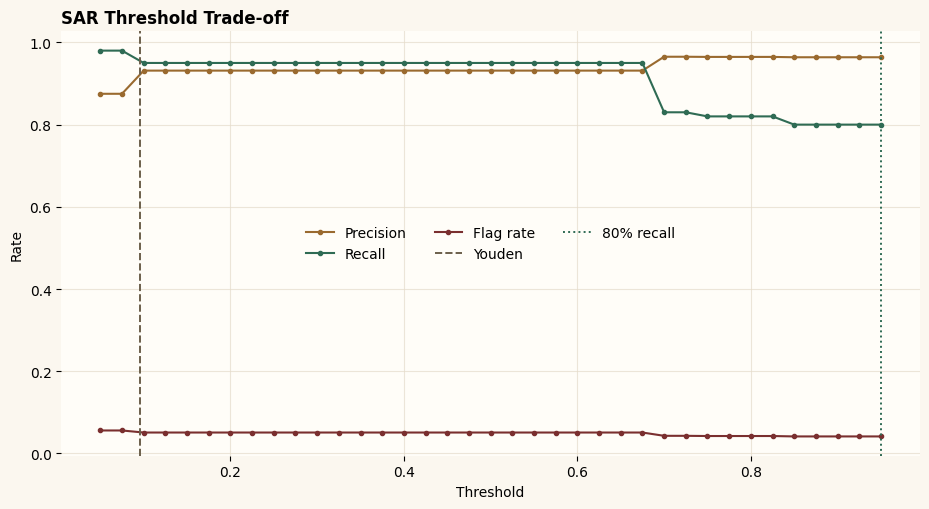

,threshold,n_flagged,tp,fp,fn,precision,recall,fpr,workload_h,flag_rate
0,0.050,112,98,14,2,0.8750,0.98,0.0074,56.0,0.0560
1,0.075,112,98,14,2,0.8750,0.98,0.0074,56.0,0.0560
2,0.100,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
3,0.125,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
4,0.150,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
5,0.175,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
6,0.200,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
7,0.225,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
8,0.250,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510
9,0.275,102,95,7,5,0.9314,0.95,0.0037,51.0,0.0510


In [17]:
INVESTIGATOR_MIN = 30
thresh_rows = []
for thr in np.linspace(0.05, 0.95, 37):
    pred = (proba_pruned >= thr).astype(int)
    tn_t,fp_t,fn_t,tp_t = confusion_matrix(np.asarray(y_te),pred,labels=[0,1]).ravel()
    thresh_rows.append({
        'threshold': thr, 'n_flagged': int(pred.sum()),
        'tp':tp_t,'fp':fp_t,'fn':fn_t,
        'precision': tp_t/max(tp_t+fp_t,1),
        'recall':    tp_t/max(tp_t+fn_t,1),
        'fpr':       fp_t/max(fp_t+tn_t,1),
        'workload_h': pred.sum()*INVESTIGATOR_MIN/60,
        'flag_rate':  pred.mean(),
    })
threshold_table = pd.DataFrame(thresh_rows)

recall_80 = threshold_table[threshold_table['recall']>=0.80]
thr_80 = float(recall_80['threshold'].max()) if len(recall_80) else op_thr_p
row_80 = threshold_table[threshold_table['threshold']<=thr_80].iloc[-1]

print(f'Youden threshold:               {op_thr_p:.3f}')
print(f'80%-recall threshold:           {thr_80:.3f}')
print(f'  Flags at 80% recall:          {int(row_80.n_flagged)}')
print(f'  Precision at 80% recall:      {row_80.precision:.2%}')
print(f'  Investigator workload:        {row_80.workload_h:.1f} hours/run')
print(f'  FP per TP at 80% recall:      {row_80.fp/max(row_80.tp,1):.2f}')

# Plot
fig, ax = plt.subplots(figsize=(9.4,5.2),facecolor=THEME['bg'])
ax.set_facecolor(THEME['panel'])
ax.plot(threshold_table['threshold'],threshold_table['precision'],marker='.',color=THEME['accent'],label='Precision')
ax.plot(threshold_table['threshold'],threshold_table['recall'],marker='.',color=THEME['accent2'],label='Recall')
ax.plot(threshold_table['threshold'],threshold_table['flag_rate'],marker='.',color=THEME['accent3'],label='Flag rate')
ax.axvline(op_thr_p,color=THEME['muted'],ls='--',lw=1.4,label='Youden')
ax.axvline(thr_80,color=THEME['accent2'],ls=':',lw=1.4,label='80% recall')
ax.set_title('SAR Threshold Trade-off',fontweight='bold',loc='left')
ax.set_xlabel('Threshold'); ax.set_ylabel('Rate')
ax.legend(frameon=False,ncol=3)
for sp in ax.spines.values(): sp.set_visible(False)
ax.grid(color=THEME['grid'],alpha=0.7)
plt.tight_layout(); plt.show()

threshold_table.round(4)


## Part 9 — Subgroup Flag-Rate Audit

In [19]:
GROUP_COLS = ['country','customer_type','transaction_type','high_risk_country']
test_idx = X_te.index if hasattr(X_te,'index') else pd.Index(range(len(y_te)))
raw_test = X.loc[test_idx].copy()
af = raw_test.copy()
af['_actual'] = np.asarray(y_te).astype(int)
af['_score']  = proba_pruned
af['_flag']   = y_pred_p

sub_rows=[]
for col in GROUP_COLS:
    if col not in af.columns: continue
    for level in af[col].value_counts().index[:12]:
        g = af[af[col].eq(level)]
        if len(g)<20: continue
        yg=g['_actual'].to_numpy(); fg=g['_flag'].to_numpy()
        auc_g = roc_auc_score(yg,g['_score']) if len(np.unique(yg))==2 else np.nan
        tn_g,fp_g,fn_g,tp_g = confusion_matrix(yg,fg,labels=[0,1]).ravel()
        sub_rows.append({'feature':col,'segment':str(level),'n':len(g),
                         'base_rate':yg.mean(),'flag_rate':fg.mean(),'auc':auc_g,
                         'precision':tp_g/max(tp_g+fp_g,1),'recall':tp_g/max(tp_g+fn_g,1),
                         'fpr':fp_g/max(fp_g+tn_g,1)})

subgroup_audit = pd.DataFrame(sub_rows)
subgroup_audit.sort_values(['feature','n'],ascending=[True,False]).round(4)


,feature,segment,n,base_rate,flag_rate,auc,precision,recall,fpr
0,country,US,1289,0.0264,0.0326,0.9980,0.7857,0.9706,0.0072
1,country,UK,396,0.0253,0.0278,0.9949,0.8182,0.9000,0.0052
2,country,CA,172,0.0000,0.0000,NaN,0.0000,0.0000,0.0000
3,country,DE,87,0.0000,0.0230,NaN,0.0000,0.0000,0.0230
4,country,VG,26,1.0000,1.0000,NaN,1.0000,1.0000,0.0000
5,customer_type,retail,1428,0.0490,0.0525,0.9986,0.9067,0.9714,0.0052
6,customer_type,business,572,0.0524,0.0629,0.9972,0.8333,1.0000,0.0111
11,high_risk_country,0,1944,0.0226,0.0283,0.9971,0.7636,0.9545,0.0068
12,high_risk_country,1,56,1.0000,1.0000,NaN,1.0000,1.0000,0.0000
7,transaction_type,ach,864,0.0220,0.0266,0.9979,0.7826,0.9474,0.0059


## Part 10 — Score Distribution and Review Queue Prioritisation

Top decile event rate: 50.00%  (10.0× base rate of 5.00%)


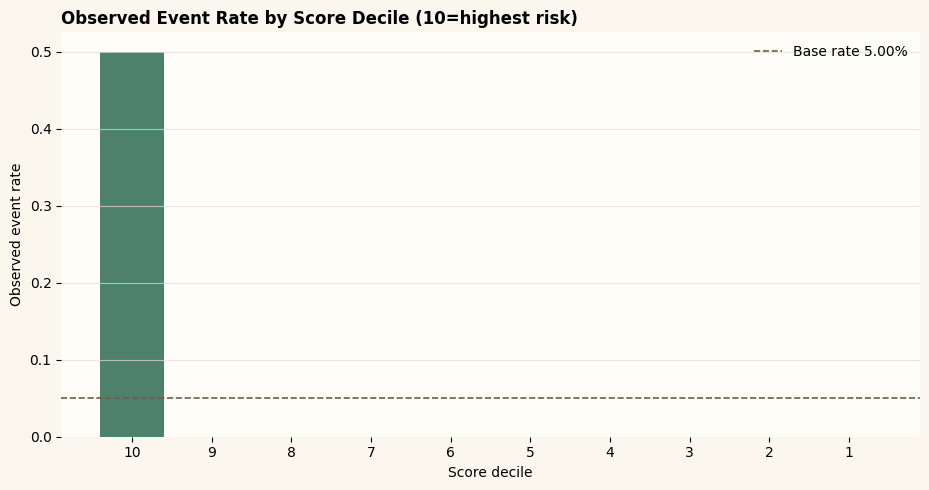

,decile,n,event_rate,avg_score,events,event_capture_pct
9,10,200,0.5,0.5010,100,1.0
8,9,200,0.0,0.0007,0,0.0
7,8,200,0.0,0.0000,0,0.0
6,7,200,0.0,0.0000,0,0.0
5,6,200,0.0,0.0000,0,0.0
4,5,200,0.0,0.0000,0,0.0
3,4,200,0.0,0.0000,0,0.0
2,3,200,0.0,0.0000,0,0.0
1,2,200,0.0,0.0000,0,0.0
0,1,200,0.0,0.0000,0,0.0


In [21]:
score_df = pd.DataFrame({'actual':np.asarray(y_te).astype(int),'score':proba_pruned})
score_df['decile'] = pd.qcut(score_df['score'].rank(method='first'),10,labels=range(1,11)).astype(int)
decile = score_df.groupby('decile').agg(
    n=('actual','size'),event_rate=('actual','mean'),
    avg_score=('score','mean'),events=('actual','sum')
).reset_index()
decile['event_capture_pct'] = decile['events']/max(decile['events'].sum(),1)
decile = decile.sort_values('decile',ascending=False)

base = float(score_df['actual'].mean())
top_d = float(decile[decile['decile'].eq(10)]['event_rate'].iloc[0])
print(f'Top decile event rate: {top_d:.2%}  ({top_d/base:.1f}× base rate of {base:.2%})')

fig,ax = plt.subplots(figsize=(9.4,5.0),facecolor=THEME['bg'])
ax.set_facecolor(THEME['panel'])
ax.bar(decile['decile'].astype(str),decile['event_rate'],color=THEME['accent2'],alpha=0.85)
ax.axhline(base,color=THEME['muted'],ls='--',lw=1.2,label=f'Base rate {base:.2%}')
ax.set_title('Observed Event Rate by Score Decile (10=highest risk)',fontweight='bold',loc='left')
ax.set_xlabel('Score decile'); ax.set_ylabel('Observed event rate')
ax.legend(frameon=False)
for sp in ax.spines.values(): sp.set_visible(False)
ax.grid(axis='y',color=THEME['grid'],alpha=0.7)
plt.tight_layout(); plt.show()

decile.round(4)


## Part 11 — Covariate Drift Detection (PSI)

AML environments shift continuously as typologies evolve and sanctions lists change.
We simulate a **high-velocity / structuring-heavy** deployment window and compute PSI.


In [26]:
def compute_psi(expected, actual, buckets=10):
    rows=[]
    common = expected.select_dtypes(include=[np.number]).columns.intersection(actual.columns)
    for col in common:
        edges = np.percentile(expected[col].dropna(),np.linspace(0,100,buckets+1))
        edges[0]=-np.inf; edges[-1]=np.inf
        ep=np.maximum(np.histogram(expected[col],bins=edges)[0]/len(expected),1e-6)
        ap=np.maximum(np.histogram(actual[col],  bins=edges)[0]/len(actual),  1e-6)
        psi=float(np.sum((ap-ep)*np.log(ap/ep)))
        rows.append({'feature':col,'psi':round(psi,4),
                     'status':'STABLE' if psi<0.10 else 'WARNING' if psi<0.25 else 'SHIFT'})
    return pd.DataFrame(rows).sort_values('psi',ascending=False)

rng_d = np.random.default_rng(77)
n_d = 500
X_raw_train = X[num_feats].iloc[:6000]
X_raw_drift = pd.DataFrame({
    'amount':                     rng_d.lognormal(9.5,0.7,n_d),
    'velocity_24h':               rng_d.integers(10,20,n_d),
    'account_age_days':           rng_d.uniform(0,60,n_d),
    'structuring_score':          rng_d.uniform(0.6,1.0,n_d),
    'avg_monthly_balance':        rng_d.lognormal(7.5,1.2,n_d),
    'num_previous_transactions':  rng_d.integers(0,5,n_d),
    'customer_age':               rng_d.integers(18,35,n_d),
    'hour_of_day':                rng_d.integers(0,5,n_d),
})
X_raw_drift = X_raw_drift[[c for c in X_raw_drift.columns if c in X_raw_train.columns]]

psi_df = compute_psi(X_raw_train, X_raw_drift)
print('PSI vs simulated high-velocity / structuring-heavy window:')
print(psi_df.to_string(index=False))
print('\nInterpretation: <0.10 stable | 0.10-0.25 warn | >0.25 significant shift')


PSI vs simulated high-velocity / structuring-heavy window:
                  feature     psi status
              hour_of_day 15.8787  SHIFT
             velocity_24h 12.7248  SHIFT
num_previous_transactions 12.6506  SHIFT
        structuring_score 12.4339  SHIFT
                   amount 10.6266  SHIFT
         account_age_days 10.5352  SHIFT
             customer_age  9.2424  SHIFT
      avg_monthly_balance  0.5468  SHIFT

Interpretation: <0.10 stable | 0.10-0.25 warn | >0.25 significant shift


## Part 12 — Model Governance and Artifact Export

In [28]:
card = generate_model_card(
    clf_pruned,
    model_id='aml-txn-monitor-v1.0',
    intended_use=(
        'Real-time transaction scoring for AML/BSA suspicious activity detection. '
        'Output feeds SAR filing queue prioritisation.'
    ),
    out_of_scope_use=(
        'Not validated for OFAC sanctions screening. '
        'Not for customer onboarding KYC risk scoring.'
    ),
    training_data_description=(
        'Synthetic AML dataset, 10,000 transactions, 12 features. '
        '5% suspicious rate. 60/20/20 train/calibration/test split.'
    ),
    evaluation_data_description='Stratified 20% holdout; 100 suspicious transactions in test set.',
    performance_metrics={
        'AUC-ROC':            round(auc_pruned,4),
        'Average_Precision':  round(ap_pruned,4),
        'ECE':                round(cal_post.ece,4),
        'BrierScore':         round(cal_post.brier_score,4),
    },
    limitations=[
        'Trained on synthetic data — production requires validation on confirmed SAR dispositions.',
        'Weak customer_age patterns removed; geographic-risk patterns retained per FinCEN guidance.',
        'Model does not replace human investigator judgment for SAR filing decisions.',
        'Monthly PSI monitoring required — AML typologies evolve rapidly.',
    ],
    ethical_considerations=(
        'Low-signal age patterns removed per BSA disparate-impact guidance. '
        'Subgroup flag-rate audit required quarterly. '
        'All flagging decisions reviewable via pattern-level explanations.'
    ),
)

print(card.to_markdown())
card.save('nb05_aml_model_card.json')
editor.save_audit_report('nb05_aml_audit_trail.json')
importances.to_csv('nb05_aml_pattern_inventory.csv',index=False)
threshold_table.to_csv('nb05_aml_threshold_grid.csv',index=False)
subgroup_audit.to_csv('nb05_aml_subgroup_audit.csv',index=False)
psi_df.to_csv('nb05_aml_psi_report.csv',index=False)
print('\n✓ Governance artifacts saved.')


# Model Card: aml-txn-monitor-v1.0

**Type:** HUGIMLClassifierNative  
**License:** Apache-2.0  
**Created:** 2026-05-29T01:08:35Z  
**Framework:** hugiml-core 1.1.2

## Reference

Krishnamoorthy, S. (2024). Interpretable Classifier Models for Decision Support Using High Utility Gain Patterns. IEEE Access, 12, 126088-126107. DOI: 10.1109/ACCESS.2024.3455563

## Intended Use

Real-time transaction scoring for AML/BSA suspicious activity detection. Output feeds SAR filing queue prioritisation.

## Out-of-Scope Use

Not validated for OFAC sanctions screening. Not for customer onboarding KYC risk scoring.

## Training Data

Synthetic AML dataset, 10,000 transactions, 12 features. 5% suspicious rate. 60/20/20 train/calibration/test split.

## Evaluation Data

Stratified 20% holdout; 100 suspicious transactions in test set.

## Hyperparameters

- **B**: 10
- **L**: 1
- **G**: 0.0005
- **topK**: 100
- **adaptive_binning**: False
- **feature_mode**: patterns_only

## Performance Metrics

- **A